# Анализ и визуализация результатов финального Fine-tuning (SSL-энкодер на 7 каналах 15 эпохи!) на Benchmark-выборке: 4 стратегии и Scratch

### Импорты и базовые настройки

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)

In [3]:
COLORS = {
    "scratch": "black",
    "partial_ft": "pink",
    "warmup": "purple",
    "full_ft": "blue",
    "low_lr_encoder": "red"
}

STRATEGY_RU = {
    "scratch": "Обучение с нуля",
    "full_ft": "Полный fine-tuning",
    "low_lr_encoder": "Замедленное дообучение энкодера",
    "partial_ft": "Частичный fine-tuning",
    "warmup": "Двухэтапное дообучение энкодера",
}

STRATEGY_ORDER = [
    "scratch",
    "full_ft",
    "low_lr_encoder",
    "partial_ft",
    "warmup",
]

### Пути

In [4]:
# === INPUT PATHS ===

NOTEBOOK_DIR = Path.cwd()

PROJECT_ROOT = NOTEBOOK_DIR.parents[2]  

OUTPUTS_DIR = PROJECT_ROOT / "outputs"  / "downstream" / "test_ch7_15epochs"

# === OUTPUT DIRS ===
FIG_DIR = OUTPUTS_DIR / "figures"
TAB_DIR = OUTPUTS_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

FT_CSV = TAB_DIR / 'FT_strategies_summary.csv'
SCRATCH_CSV = TAB_DIR / 'Scratch_summary.csv'


print("FT_CSV exists:", FT_CSV.exists(), FT_CSV)
print("SCRATCH_CSV exists:", SCRATCH_CSV.exists(), SCRATCH_CSV)
print("Output dir:", OUTPUTS_DIR.resolve())

FT_CSV exists: True c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_ch7_15epochs\tables\FT_strategies_summary.csv
SCRATCH_CSV exists: True c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_ch7_15epochs\tables\Scratch_summary.csv
Output dir: C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_ch7_15epochs


### Загрузка файлов

In [ ]:
df_ft = pd.read_csv(FT_CSV)
df_scratch = pd.read_csv(SCRATCH_CSV)

print("df_ft shape:", df_ft.shape)
print("df_scratch shape:", df_scratch.shape)

display(df_ft.head())
display(df_scratch.head())

df_ft shape: (1220, 36)
df_scratch shape: (305, 36)


,subject_id,group,p,scenario,channel_set,n_channels,channels,ft_strategy,seed,encoder_checkpoint,lr_encoder,lr_head,weight_decay,warmup_epochs,selected_threshold,val_f1_at_selected_threshold,n_calib,n_val,n_test,n_pos_calib,n_pos_val,n_pos_test,best_epoch,best_val_loss,stopped_epoch,auc,accuracy,f1,precision,recall,fdr,run_tag,history_path,predictions_path,status,error
0,subj_051,benchmark,10,ssl_ft,ch7,7,"Cz,Pz,Oz,P3,P4,PO7,PO8",full_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-7-ch...,0.00003,0.0003,0.001,NaN,0.050,0.214286,623,125,2670,74,15,314,1,0.711585,11,0.474411,0.117603,0.210456,0.117603,1.000000,0.006504,ch7__benchmark__subj_051__p10__ssl_ft__seed42_...,/kaggle/working/stage5_results/channel_ablatio...,/kaggle/working/stage5_results/channel_ablatio...,ok,NaN
1,subj_051,benchmark,10,ssl_ft,ch7,7,"Cz,Pz,Oz,P3,P4,PO7,PO8",low_lr_encoder,42,/kaggle/input/datasets/taisiyaglazova/ssl-7-ch...,0.00003,0.0003,0.001,NaN,0.400,0.218978,623,125,2670,74,15,314,7,0.679079,17,0.561869,0.142322,0.207612,0.116460,0.955414,0.021535,ch7__benchmark__subj_051__p10__ssl_ft__seed42_...,/kaggle/working/stage5_results/channel_ablatio...,/kaggle/working/stage5_results/channel_ablatio...,ok,NaN
2,subj_051,benchmark,10,ssl_ft,ch7,7,"Cz,Pz,Oz,P3,P4,PO7,PO8",partial_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-7-ch...,0.00003,0.0003,0.001,NaN,0.395,0.254545,623,125,2670,74,15,314,23,0.674927,33,0.563124,0.284644,0.222313,0.127451,0.869427,0.020991,ch7__benchmark__subj_051__p10__ssl_ft__seed42_...,/kaggle/working/stage5_results/channel_ablatio...,/kaggle/working/stage5_results/channel_ablatio...,ok,NaN
3,subj_051,benchmark,10,ssl_ft,ch7,7,"Cz,Pz,Oz,P3,P4,PO7,PO8",warmup,42,/kaggle/input/datasets/taisiyaglazova/ssl-7-ch...,0.00003,0.0003,0.001,3.0,0.375,0.243902,623,125,2670,74,15,314,7,0.683360,17,0.561710,0.201124,0.214943,0.121515,0.929936,0.020417,ch7__benchmark__subj_051__p10__ssl_ft__seed42_...,/kaggle/working/stage5_results/channel_ablatio...,/kaggle/working/stage5_results/channel_ablatio...,ok,NaN
4,subj_051,benchmark,20,ssl_ft,ch7,7,"Cz,Pz,Oz,P3,P4,PO7,PO8",full_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-7-ch...,0.00003,0.0003,0.001,NaN,0.050,0.214286,1246,250,2670,148,30,314,1,0.697746,11,0.494658,0.117603,0.210456,0.117603,1.000000,0.000939,ch7__benchmark__subj_051__p20__ssl_ft__seed42_...,/kaggle/working/stage5_results/channel_ablatio...,/kaggle/working/stage5_results/channel_ablatio...,ok,NaN


,subject_id,group,p,scenario,channel_set,n_channels,channels,ft_strategy,seed,encoder_checkpoint,lr_encoder,lr_head,weight_decay,warmup_epochs,selected_threshold,val_f1_at_selected_threshold,n_calib,n_val,n_test,n_pos_calib,n_pos_val,n_pos_test,best_epoch,best_val_loss,stopped_epoch,auc,accuracy,f1,precision,recall,fdr,run_tag,history_path,predictions_path,status,error
0,subj_051,benchmark,10,scratch,ch7,7,"Cz,Pz,Oz,P3,P4,PO7,PO8",NaN,42,NaN,NaN,NaN,0.0001,NaN,0.050,0.214286,623,125,2670,74,15,314,1,0.704079,11,0.502426,0.117603,0.210456,0.117603,1.000000,9.898058e-07,ch7__benchmark__subj_051__p10__scratch__seed42...,/kaggle/working/stage5_results/channel_ablatio...,/kaggle/working/stage5_results/channel_ablatio...,ok,NaN
1,subj_051,benchmark,20,scratch,ch7,7,"Cz,Pz,Oz,P3,P4,PO7,PO8",NaN,42,NaN,NaN,NaN,0.0001,NaN,0.050,0.214286,1246,250,2670,148,30,314,1,0.697486,11,0.557633,0.117603,0.210456,0.117603,1.000000,1.260512e-02,ch7__benchmark__subj_051__p20__scratch__seed42...,/kaggle/working/stage5_results/channel_ablatio...,/kaggle/working/stage5_results/channel_ablatio...,ok,NaN
2,subj_051,benchmark,40,scratch,ch7,7,"Cz,Pz,Oz,P3,P4,PO7,PO8",NaN,42,NaN,NaN,NaN,0.0001,NaN,0.285,0.219239,2492,499,2670,296,59,314,1,0.756707,11,0.509396,0.303371,0.205128,0.118460,0.764331,1.850263e-05,ch7__benchmark__subj_051__p40__scratch__seed42...,/kaggle/working/stage5_results/channel_ablatio...,/kaggle/working/stage5_results/channel_ablatio...,ok,NaN
3,subj_051,benchmark,60,scratch,ch7,7,"Cz,Pz,Oz,P3,P4,PO7,PO8",NaN,42,NaN,NaN,NaN,0.0001,NaN,0.335,0.217338,3738,748,2670,444,89,314,1,0.726550,11,0.596485,0.140075,0.213160,0.119432,0.990446,3.723525e-02,ch7__benchmark__subj_051__p60__scratch__seed42...,/kaggle/working/stage5_results/channel_ablatio...,/kaggle/working/stage5_results/channel_ablatio...,ok,NaN
4,subj_051,benchmark,100,scratch,ch7,7,"Cz,Pz,Oz,P3,P4,PO7,PO8",NaN,42,NaN,NaN,NaN,0.0001,NaN,0.395,0.461538,6230,1246,2670,740,148,314,3,0.496492,13,0.791597,0.744195,0.386343,0.269086,0.684713,6.798146e-01,ch7__benchmark__subj_051__p100__scratch__seed4...,/kaggle/working/stage5_results/channel_ablatio...,/kaggle/working/stage5_results/channel_ablatio...,ok,NaN


In [ ]:
print("FT columns:")
print(df_ft.columns.tolist())

print("\nScratch columns:")
print(df_scratch.columns.tolist())

FT columns:
['subject_id', 'group', 'p', 'scenario', 'channel_set', 'n_channels', 'channels', 'ft_strategy', 'seed', 'encoder_checkpoint', 'lr_encoder', 'lr_head', 'weight_decay', 'warmup_epochs', 'selected_threshold', 'val_f1_at_selected_threshold', 'n_calib', 'n_val', 'n_test', 'n_pos_calib', 'n_pos_val', 'n_pos_test', 'best_epoch', 'best_val_loss', 'stopped_epoch', 'auc', 'accuracy', 'f1', 'precision', 'recall', 'fdr', 'run_tag', 'history_path', 'predictions_path', 'status', 'error']

Scratch columns:
['subject_id', 'group', 'p', 'scenario', 'channel_set', 'n_channels', 'channels', 'ft_strategy', 'seed', 'encoder_checkpoint', 'lr_encoder', 'lr_head', 'weight_decay', 'warmup_epochs', 'selected_threshold', 'val_f1_at_selected_threshold', 'n_calib', 'n_val', 'n_test', 'n_pos_calib', 'n_pos_val', 'n_pos_test', 'best_epoch', 'best_val_loss', 'stopped_epoch', 'auc', 'accuracy', 'f1', 'precision', 'recall', 'fdr', 'run_tag', 'history_path', 'predictions_path', 'status', 'error']


### Приведение с единому формату и Объединение таблиц (только нужные признаки)

In [ ]:
# --- копии ---
df_ft = df_ft.copy()
df_scratch = df_scratch.copy()

# --- создаём strategy ---
df_ft["strategy"] = df_ft["ft_strategy"].astype(str)
df_scratch["strategy"] = "scratch"

# --- приводим p ---
df_ft["p"] = df_ft["p"].astype(int)
df_scratch["p"] = df_scratch["p"].astype(int)

# --- оставляем только нужные колонки ---
core_cols = [
    "subject_id",
    "p",
    "strategy",
    "auc",
    "f1",
    "accuracy",
    "precision",
    "recall",
    "fdr"
]

optional_cols = ["group"]  # можно убрать, если не нужен

keep_cols = core_cols + optional_cols

df_ft = df_ft[keep_cols]
df_scratch = df_scratch[keep_cols]

# --- объединяем ---
df_all = pd.concat([df_ft, df_scratch], ignore_index=True)

print("df_all shape:", df_all.shape)
display(df_all.head())

df_all shape: (1525, 10)


,subject_id,p,strategy,auc,f1,accuracy,precision,recall,fdr,group
0,subj_051,10,full_ft,0.474411,0.210456,0.117603,0.117603,1.000000,0.006504,benchmark
1,subj_051,10,low_lr_encoder,0.561869,0.207612,0.142322,0.116460,0.955414,0.021535,benchmark
2,subj_051,10,partial_ft,0.563124,0.222313,0.284644,0.127451,0.869427,0.020991,benchmark
3,subj_051,10,warmup,0.561710,0.214943,0.201124,0.121515,0.929936,0.020417,benchmark
4,subj_051,20,full_ft,0.494658,0.210456,0.117603,0.117603,1.000000,0.000939,benchmark


#### Проверка базовых значений

In [ ]:
print("Unique strategies:", sorted(df_all["strategy"].dropna().unique().tolist()))
print("Unique p:", sorted(df_all["p"].dropna().unique().tolist()))
print("Number of subjects:", df_all["subject_id"].nunique())

Unique strategies: ['full_ft', 'low_lr_encoder', 'partial_ft', 'scratch', 'warmup']
Unique p: [10, 20, 40, 60, 100]
Number of subjects: 61


#### Проверка ключевых метрик и обязательных колонок

In [ ]:
required_cols = [
    "subject_id", "p", "strategy",
    "auc", "f1", "accuracy", "precision", "recall", "fdr"
]

missing_required = [c for c in required_cols if c not in df_all.columns]
print("Missing required columns:", missing_required)

Missing required columns: []


#### Проверка дубликатов по ключу subject_id × p × strategy

In [ ]:
key_cols = ["subject_id", "p", "strategy"]

dup_mask = df_all.duplicated(subset=key_cols, keep=False)
df_dups = df_all.loc[dup_mask].sort_values(key_cols)

print("Number of duplicated rows by key:", len(df_dups))
display(df_dups.head(20))

Number of duplicated rows by key: 0


,subject_id,p,strategy,auc,f1,accuracy,precision,recall,fdr,group


#### Проверка пропусков в метриках

In [ ]:
metric_cols = ["auc", "f1", "accuracy", "precision", "recall", "fdr"]

na_report = df_all[metric_cols].isna().sum().sort_values(ascending=False)
print("NaN counts in metrics:")
display(na_report.to_frame("n_missing"))

NaN counts in metrics:


,n_missing
auc,0
f1,0
accuracy,0
precision,0
recall,0
fdr,0


In [ ]:
# Проверка пропусков по стратегиям
na_by_strategy = df_all.groupby("strategy")[metric_cols].apply(lambda x: x.isna().sum())
display(na_by_strategy)

,auc,f1,accuracy,precision,recall,fdr
strategy,,,,,,
full_ft,0,0,0,0,0,0
low_lr_encoder,0,0,0,0,0,0
partial_ft,0,0,0,0,0,0
scratch,0,0,0,0,0,0
warmup,0,0,0,0,0,0


#### Проверка числа наблюдений по стратегиям и по p

In [ ]:
count_by_strategy_p = (
    df_all.groupby(["strategy", "p"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

display(count_by_strategy_p)

p,10,20,40,60,100
strategy,,,,,
full_ft,61,61,61,61,61
low_lr_encoder,61,61,61,61,61
partial_ft,61,61,61,61,61
scratch,61,61,61,61,61
warmup,61,61,61,61,61


#### Проверка парности по субъектам

In [ ]:
subjects_by_strategy_p = (
    df_all.groupby(["strategy", "p"])["subject_id"]
    .apply(lambda s: set(s.tolist()))
)

all_strategies = sorted(df_all["strategy"].unique())
all_p = sorted(df_all["p"].unique())

pairing_report = []

for p in all_p:
    base_subjects = subjects_by_strategy_p.get(("scratch", p), set())
    for strategy in all_strategies:
        cur_subjects = subjects_by_strategy_p.get((strategy, p), set())
        pairing_report.append({
            "p": p,
            "strategy": strategy,
            "n_subjects": len(cur_subjects),
            "same_as_scratch": cur_subjects == base_subjects,
            "missing_vs_scratch": len(base_subjects - cur_subjects),
            "extra_vs_scratch": len(cur_subjects - base_subjects),
        })

pairing_report_df = pd.DataFrame(pairing_report).sort_values(["p", "strategy"])
display(pairing_report_df)

,p,strategy,n_subjects,same_as_scratch,missing_vs_scratch,extra_vs_scratch
0,10,full_ft,61,True,0,0
1,10,low_lr_encoder,61,True,0,0
2,10,partial_ft,61,True,0,0
3,10,scratch,61,True,0,0
4,10,warmup,61,True,0,0
5,20,full_ft,61,True,0,0
6,20,low_lr_encoder,61,True,0,0
7,20,partial_ft,61,True,0,0
8,20,scratch,61,True,0,0
9,20,warmup,61,True,0,0


### Сохраняем промежуточную объединённую таблицу

In [ ]:
# df_all.to_csv(TAB_DIR / "combined_all_results.csv", index=False)
# pairing_report_df.to_csv(TAB_DIR / "pairing_report.csv", index=False)
# count_by_strategy_p.to_csv(TAB_DIR / "count_by_strategy_p.csv")

### Короткий автоматический sanity-check

In [ ]:
expected_strategies = {"scratch", "full_ft", "low_lr_encoder", "partial_ft", "warmup"}
expected_p = {10, 20, 40, 60, 100}

actual_strategies = set(df_all["strategy"].dropna().unique())
actual_p = set(df_all["p"].dropna().unique())

print("Strategies OK:", actual_strategies == expected_strategies)
print("p values OK:", actual_p == expected_p)
print("No duplicate keys:", len(df_dups) == 0)
print("No missing metrics:", df_all[metric_cols].isna().sum().sum() == 0)

Strategies OK: True
p values OK: True
No duplicate keys: True
No missing metrics: True


## Формирование финальной аналитической таблицы

#### Базовая агрегация

In [ ]:
metric_cols = ["auc", "f1", "accuracy", "precision", "recall", "fdr"]

summary = (
    df_all
    .groupby(["strategy", "p"])[metric_cols]
    .agg(["mean", "std", "median"])
)

# flatten columns
summary.columns = ["_".join(col) for col in summary.columns]

# добавим число субъектов
n_subjects = (
    df_all
    .groupby(["strategy", "p"])["subject_id"]
    .nunique()
    .rename("n_subjects")
)

summary = summary.join(n_subjects)

summary = summary.reset_index()

display(summary.head())

,strategy,p,auc_mean,auc_std,auc_median,f1_mean,f1_std,f1_median,accuracy_mean,accuracy_std,accuracy_median,precision_mean,precision_std,precision_median,recall_mean,recall_std,recall_median,fdr_mean,fdr_std,fdr_median,n_subjects
0,full_ft,10,0.517228,0.053084,0.505023,0.226561,0.080483,0.201511,0.236875,0.183636,0.168761,0.134964,0.055091,0.117405,0.883937,0.206317,0.998748,0.023622,0.133479,0.001028,61
1,full_ft,20,0.536498,0.066797,0.517870,0.228291,0.078342,0.210436,0.290062,0.202880,0.247857,0.138429,0.055886,0.117647,0.831487,0.223053,0.931880,0.049076,0.243055,0.001627,61
2,full_ft,40,0.565321,0.094614,0.537243,0.249444,0.105294,0.212601,0.299369,0.196153,0.253635,0.152426,0.087277,0.122061,0.865458,0.152917,0.914062,0.146782,0.587124,0.005258,61
3,full_ft,60,0.619609,0.118698,0.573949,0.278609,0.121418,0.231250,0.368838,0.231111,0.304946,0.177880,0.110062,0.132358,0.859650,0.129398,0.885106,0.286999,0.776044,0.024146,61
4,full_ft,100,0.716421,0.123045,0.710667,0.343355,0.126205,0.348884,0.568433,0.223185,0.618165,0.234373,0.118217,0.226500,0.777802,0.112697,0.757764,0.620445,0.967216,0.303419,61


#### Отдельная таблица mean ± std

In [ ]:
def mean_std_str(mean, std):
    return f"{mean:.4f} ± {std:.4f}"

table_mean_std = summary.copy()

for m in ["auc", "f1", "accuracy"]:
    table_mean_std[f"{m}_mean_std"] = table_mean_std.apply(
        lambda row: mean_std_str(row[f"{m}_mean"], row[f"{m}_std"]),
        axis=1
    )

cols_for_table = [
    "strategy", "p", "n_subjects",
    "auc_mean_std",
    "f1_mean_std",
    "accuracy_mean_std"
]

table_mean_std = table_mean_std[cols_for_table]

display(table_mean_std)

,strategy,p,n_subjects,auc_mean_std,f1_mean_std,accuracy_mean_std
0,full_ft,10,61,0.5172 ± 0.0531,0.2266 ± 0.0805,0.2369 ± 0.1836
1,full_ft,20,61,0.5365 ± 0.0668,0.2283 ± 0.0783,0.2901 ± 0.2029
2,full_ft,40,61,0.5653 ± 0.0946,0.2494 ± 0.1053,0.2994 ± 0.1962
3,full_ft,60,61,0.6196 ± 0.1187,0.2786 ± 0.1214,0.3688 ± 0.2311
4,full_ft,100,61,0.7164 ± 0.1230,0.3434 ± 0.1262,0.5684 ± 0.2232
5,low_lr_encoder,10,61,0.5172 ± 0.0489,0.2278 ± 0.0796,0.2089 ± 0.1435
6,low_lr_encoder,20,61,0.5308 ± 0.0524,0.2294 ± 0.0778,0.2377 ± 0.1423
7,low_lr_encoder,40,61,0.5432 ± 0.0717,0.2351 ± 0.0838,0.2053 ± 0.1271
8,low_lr_encoder,60,61,0.5534 ± 0.0818,0.2426 ± 0.0981,0.2287 ± 0.1699
9,low_lr_encoder,100,61,0.5924 ± 0.1034,0.2606 ± 0.1093,0.3195 ± 0.2110


#### Pivot-таблица

In [ ]:
pivot_auc = table_mean_std.pivot(index="p", columns="strategy", values="auc_mean_std")
pivot_f1 = table_mean_std.pivot(index="p", columns="strategy", values="f1_mean_std")
pivot_acc = table_mean_std.pivot(index="p", columns="strategy", values="accuracy_mean_std")

print("AUC:")
display(pivot_auc)

print("\nF1:")
display(pivot_f1)

print("\nAccuracy:")
display(pivot_acc)

AUC:


strategy,full_ft,low_lr_encoder,partial_ft,scratch,warmup
p,,,,,
10,0.5172 ± 0.0531,0.5172 ± 0.0489,0.5240 ± 0.0548,0.5115 ± 0.0533,0.5217 ± 0.0490
20,0.5365 ± 0.0668,0.5308 ± 0.0524,0.5346 ± 0.0639,0.5190 ± 0.0638,0.5342 ± 0.0592
40,0.5653 ± 0.0946,0.5432 ± 0.0717,0.5579 ± 0.0814,0.5397 ± 0.0812,0.5468 ± 0.0730
60,0.6196 ± 0.1187,0.5534 ± 0.0818,0.5792 ± 0.0917,0.5759 ± 0.0991,0.5585 ± 0.0824
100,0.7164 ± 0.1230,0.5924 ± 0.1034,0.6169 ± 0.1062,0.6593 ± 0.1368,0.5993 ± 0.1045



F1:


strategy,full_ft,low_lr_encoder,partial_ft,scratch,warmup
p,,,,,
10,0.2266 ± 0.0805,0.2278 ± 0.0796,0.2303 ± 0.0801,0.2310 ± 0.0863,0.2293 ± 0.0800
20,0.2283 ± 0.0783,0.2294 ± 0.0778,0.2343 ± 0.0824,0.2307 ± 0.0839,0.2317 ± 0.0798
40,0.2494 ± 0.1053,0.2351 ± 0.0838,0.2432 ± 0.0895,0.2388 ± 0.1001,0.2364 ± 0.0837
60,0.2786 ± 0.1214,0.2426 ± 0.0981,0.2517 ± 0.0905,0.2528 ± 0.1098,0.2434 ± 0.0958
100,0.3434 ± 0.1262,0.2606 ± 0.1093,0.2687 ± 0.0966,0.3077 ± 0.1269,0.2649 ± 0.1115



Accuracy:


strategy,full_ft,low_lr_encoder,partial_ft,scratch,warmup
p,,,,,
10,0.2369 ± 0.1836,0.2089 ± 0.1435,0.2206 ± 0.1374,0.1548 ± 0.1203,0.2103 ± 0.1376
20,0.2901 ± 0.2029,0.2377 ± 0.1423,0.2292 ± 0.1698,0.1725 ± 0.1346,0.2296 ± 0.1375
40,0.2994 ± 0.1962,0.2053 ± 0.1271,0.2671 ± 0.1782,0.2931 ± 0.1915,0.2262 ± 0.1339
60,0.3688 ± 0.2311,0.2287 ± 0.1699,0.3095 ± 0.1994,0.3202 ± 0.2137,0.2469 ± 0.1698
100,0.5684 ± 0.2232,0.3195 ± 0.2110,0.3820 ± 0.2120,0.4471 ± 0.2594,0.3335 ± 0.2199


#### Сохраняем таблицы

In [ ]:
# summary.to_csv(TAB_DIR / "summary_full_stats.csv", index=False)
# table_mean_std.to_csv(TAB_DIR / "summary_mean_std.csv", index=False)

# pivot_auc.to_csv(TAB_DIR / "pivot_auc.csv")
# pivot_f1.to_csv(TAB_DIR / "pivot_f1.csv")
# pivot_acc.to_csv(TAB_DIR / "pivot_accuracy.csv")

## Основные графики

- ROC-AUC vs p
- F1 vs p
- Accuracy vs p

#### Подготовка данных для графиков

In [21]:
plot_df = (
    df_all
    .groupby(["strategy", "p"])[["auc", "f1", "accuracy"]]
    .agg(["mean", "std"])
)

plot_df.columns = ["_".join(col) for col in plot_df.columns]
plot_df = plot_df.reset_index()

display(plot_df.head())

,strategy,p,auc_mean,auc_std,f1_mean,f1_std,accuracy_mean,accuracy_std
0,full_ft,10,0.517228,0.053084,0.226561,0.080483,0.236875,0.183636
1,full_ft,20,0.536498,0.066797,0.228291,0.078342,0.290062,0.202880
2,full_ft,40,0.565321,0.094614,0.249444,0.105294,0.299369,0.196153
3,full_ft,60,0.619609,0.118698,0.278609,0.121418,0.368838,0.231111
4,full_ft,100,0.716421,0.123045,0.343355,0.126205,0.568433,0.223185


#### Функция для построения графика

In [22]:
def make_strategy_label(row):
    scenario = row.get("scenario", None)
    ft_strategy = row.get("ft_strategy", None)

    if scenario == "scratch":
        return "С нуля"
    if pd.notna(ft_strategy):
        return STRATEGY_RU.get(ft_strategy, str(ft_strategy))
    return str(scenario)

In [30]:
def draw_metric_plot(metric, ylabel):
    fig, ax = plt.subplots(figsize=(7, 5))

    p_values = [10, 20, 40, 60, 100]

    strategies_present = [
        s for s in STRATEGY_ORDER
        if s in plot_df["strategy"].unique()
    ]

    for strategy in strategies_present:
        sub = plot_df[plot_df["strategy"] == strategy].copy()
        sub = sub.set_index("p").loc[p_values].reset_index()

        x = sub["p"]
        y = sub[f"{metric}_mean"]
        yerr = sub[f"{metric}_std"]

        linestyle = "--" if strategy == "scratch" else "-"

        ax.plot(
            x, y,
            marker="o",
            linewidth=2,
            linestyle=linestyle,
            color=COLORS[strategy],
            label=STRATEGY_RU.get(strategy, strategy),
        )

        ax.errorbar(
            x, y,
            yerr=yerr,
            fmt="none",
            ecolor=COLORS[strategy],
            capsize=3,
            alpha=0.8,
        )

    ax.set_xticks(p_values)
    ax.set_xlabel("Объём калибровки p (%)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} в зависимости от объёма калибровки")
    ax.legend(title="Стратегия")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    return fig

#### Строим графики

In [24]:
def plot_metric(metric, ylabel):
    draw_metric_plot(metric, ylabel)
    plt.show()

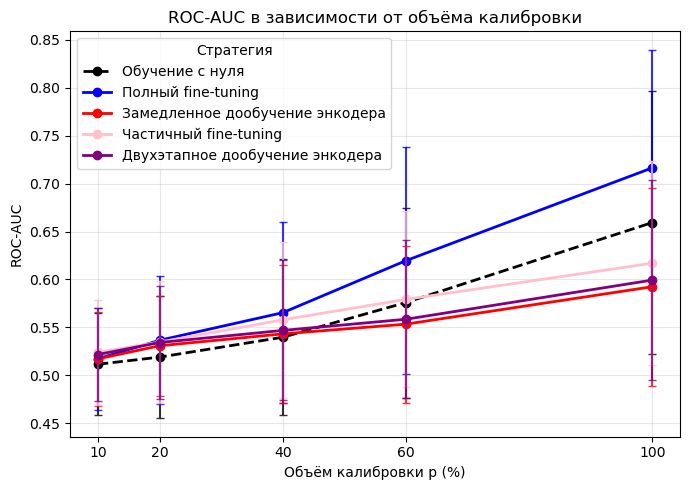

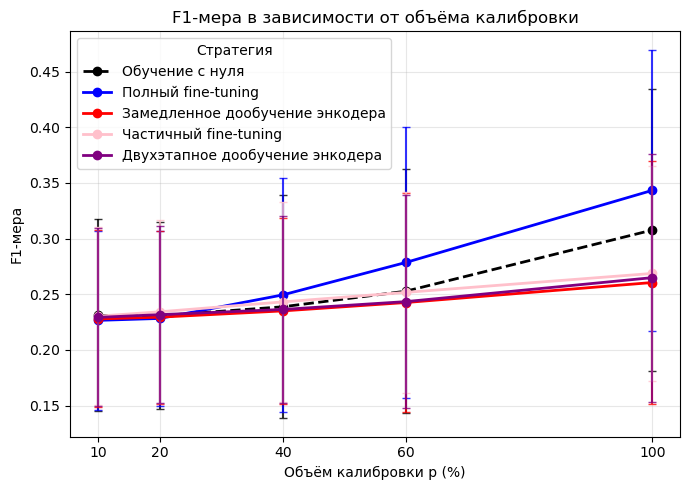

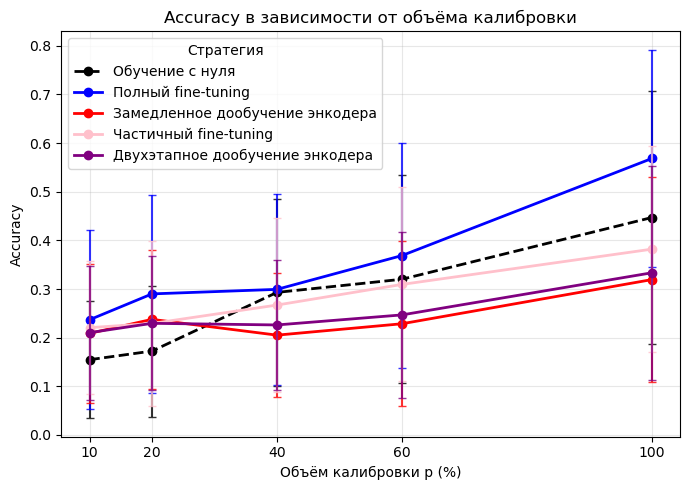

In [31]:
plot_metric("auc", "ROC-AUC")
plot_metric("f1", "F1-мера")
plot_metric("accuracy", "Accuracy")

#### Сохраняем графики

In [32]:
def save_plot(plot_func, metric, ylabel, filename):
    fig = plot_func(metric, ylabel)

    save_path = FIG_DIR / filename
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    fig.savefig(save_path.with_suffix(".pdf"), bbox_inches="tight")
    plt.close(fig)

    print(f"Сохранено: {save_path}")

In [33]:
save_plot(draw_metric_plot, "auc", "ROC-AUC", "auc_vs_p.png")
save_plot(draw_metric_plot, "f1", "F1-мера", "f1_vs_p.png")
save_plot(draw_metric_plot, "accuracy", "Accuracy", "accuracy_vs_p.png")

Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_ch7_15epochs\figures\auc_vs_p.png
Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_ch7_15epochs\figures\f1_vs_p.png
Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_ch7_15epochs\figures\accuracy_vs_p.png


## Дельты относительно scratch

#### per-subject delta

In [1]:
df_all = pd.read_csv(TAB_DIR / "combined_all_results.csv")

NameError: name 'pd' is not defined

In [5]:
metric_cols = ["auc", "f1", "accuracy"]

# scratch как база
df_scratch_base = (
    df_all[df_all["strategy"] == "scratch"]
    [["subject_id", "p"] + metric_cols]
    .rename(columns={m: f"{m}_scratch" for m in metric_cols})
    .copy()
)

# все не-scratch стратегии
df_non_scratch = df_all[df_all["strategy"] != "scratch"].copy()

# merge по subject_id и p
df_delta = df_non_scratch.merge(
    df_scratch_base,
    on=["subject_id", "p"],
    how="inner"
)

# считаем дельты
for m in metric_cols:
    df_delta[f"delta_{m}"] = df_delta[m] - df_delta[f"{m}_scratch"]

print("df_delta shape:", df_delta.shape)
display(df_delta.head())

df_delta shape: (1220, 16)


,subject_id,p,strategy,auc,f1,accuracy,precision,recall,fdr,group,auc_scratch,f1_scratch,accuracy_scratch,delta_auc,delta_f1,delta_accuracy
0,subj_051,10,full_ft,0.474411,0.210456,0.117603,0.117603,1.000000,0.006504,benchmark,0.502426,0.210456,0.117603,-0.028015,0.000000,0.000000
1,subj_051,10,low_lr_encoder,0.561869,0.207612,0.142322,0.116460,0.955414,0.021535,benchmark,0.502426,0.210456,0.117603,0.059442,-0.002843,0.024719
2,subj_051,10,partial_ft,0.563124,0.222313,0.284644,0.127451,0.869427,0.020991,benchmark,0.502426,0.210456,0.117603,0.060697,0.011857,0.167041
3,subj_051,10,warmup,0.561710,0.214943,0.201124,0.121515,0.929936,0.020417,benchmark,0.502426,0.210456,0.117603,0.059284,0.004487,0.083521
4,subj_051,20,full_ft,0.494658,0.210456,0.117603,0.117603,1.000000,0.000939,benchmark,0.557633,0.210456,0.117603,-0.062975,0.000000,0.000000


In [6]:
check_delta = (
    df_delta.groupby(["strategy", "p"])[["delta_auc", "delta_f1", "delta_accuracy"]]
    .agg(["mean", "std", "median"])
)

check_delta.columns = ["_".join(col) for col in check_delta.columns]
check_delta = check_delta.reset_index()

display(check_delta)

,strategy,p,delta_auc_mean,delta_auc_std,delta_auc_median,delta_f1_mean,delta_f1_std,delta_f1_median,delta_accuracy_mean,delta_accuracy_std,delta_accuracy_median
0,full_ft,10,0.005708,0.026855,0.003060,-0.004483,0.025256,0.000000,0.082099,0.167099,0.000000
1,full_ft,20,0.017534,0.039531,0.013539,-0.002441,0.026768,0.000000,0.117537,0.202258,0.002577
2,full_ft,40,0.025617,0.050912,0.011305,0.010673,0.031971,0.001962,0.006233,0.200025,-0.000521
3,full_ft,60,0.043698,0.054350,0.027760,0.025841,0.047648,0.006948,0.048684,0.197822,0.003669
4,full_ft,100,0.057102,0.060279,0.039773,0.035651,0.055385,0.028272,0.121364,0.177943,0.064114
5,low_lr_encoder,10,0.005658,0.033634,0.006300,-0.003205,0.019984,0.000000,0.054101,0.125764,0.000000
6,low_lr_encoder,20,0.011848,0.030812,0.009565,-0.001296,0.024404,0.000000,0.065181,0.147644,0.020408
7,low_lr_encoder,40,0.003498,0.035627,0.001380,-0.003710,0.040041,0.000000,-0.087865,0.149820,-0.040110
8,low_lr_encoder,60,-0.022545,0.054804,-0.012537,-0.010179,0.031349,-0.000113,-0.091493,0.137510,-0.030207
9,low_lr_encoder,100,-0.066917,0.087703,-0.047973,-0.047135,0.073152,-0.017046,-0.127619,0.214631,-0.079685


## Парные статистические тесты

In [7]:
# Импорт статистики
from scipy.stats import wilcoxon

#### Функция для одного теста

In [8]:
def run_wilcoxon(df, metric, alternative="two-sided"):
    values = df[metric].dropna()

    if len(values) < 5:
        return np.nan

    try:
        stat, p = wilcoxon(values, alternative=alternative)
        return p
    except Exception:
        return np.nan

### Значимо ли Δ-метрика (относительно scratch) отличается от 0?

(двусторонний тест)

In [9]:
results = []

strategies = sorted(df_delta["strategy"].unique())
p_values = sorted(df_delta["p"].unique())

metrics = ["delta_auc", "delta_f1", "delta_accuracy"]

for p in p_values:
    for strategy in strategies:
        sub = df_delta[
            (df_delta["p"] == p) &
            (df_delta["strategy"] == strategy)
        ]

        for metric in metrics:
            p_val = run_wilcoxon(sub, metric)

            results.append({
                "p": p,
                "strategy": strategy,
                "metric": metric,
                "n": len(sub),
                "mean": sub[metric].mean(),
                "median": sub[metric].median(),
                "p_value": p_val
            })

stats_df = pd.DataFrame(results)
display(stats_df.head())

,p,strategy,metric,n,mean,median,p_value
0,10,full_ft,delta_auc,61,0.005708,0.00306,0.145804
1,10,full_ft,delta_f1,61,-0.004483,0.00000,0.426621
2,10,full_ft,delta_accuracy,61,0.082099,0.00000,0.000053
3,10,low_lr_encoder,delta_auc,61,0.005658,0.00630,0.166762
4,10,low_lr_encoder,delta_f1,61,-0.003205,0.00000,0.102069


#### Поправка на множественные сравнения

In [ ]:
from statsmodels.stats.multitest import multipletests

stats_df["p_adj"] = multipletests(stats_df["p_value"], method="fdr_bh")[1]
stats_df["significant"] = stats_df["p_adj"] < 0.05

# display(stats_df)

#### Сохраняем таблицу стат анализа

In [11]:
stats_df.to_excel(TAB_DIR / "DELTAvsSCRATCH_STAT_ANALYSIS.xlsx", index=False)

#### Только значимые строки

In [43]:
significant_df = stats_df[stats_df["significant"] == True]

display(significant_df)

,p,strategy,metric,n,mean,median,p_value,p_adj,significant
2,10,full_ft,delta_accuracy,61,0.082099,0.000000,5.269831e-05,2.135212e-04,True
5,10,low_lr_encoder,delta_accuracy,61,0.054101,0.000000,3.899937e-04,8.999854e-04,True
6,10,partial_ft,delta_auc,61,0.012462,0.006151,1.088735e-02,1.814558e-02,True
8,10,partial_ft,delta_accuracy,61,0.065859,0.000000,1.004687e-04,3.545954e-04,True
9,10,warmup,delta_auc,61,0.010162,0.002562,3.034124e-02,4.790722e-02,True
11,10,warmup,delta_accuracy,61,0.055568,0.008764,2.911972e-05,1.343987e-04,True
12,20,full_ft,delta_auc,61,0.017534,0.013539,3.244175e-04,8.110437e-04,True
14,20,full_ft,delta_accuracy,61,0.117537,0.002577,8.577213e-05,3.216455e-04,True
15,20,low_lr_encoder,delta_auc,61,0.011848,0.009565,1.444736e-03,2.989110e-03,True
17,20,low_lr_encoder,delta_accuracy,61,0.065181,0.020408,8.232380e-04,1.829418e-03,True


#### Только по AUC все

In [45]:
sig_auc = stats_df[
    (stats_df["metric"] == "delta_auc") &
    (stats_df["significant"] == True)
]

display(sig_auc.sort_values(["p", "strategy"]))

,p,strategy,metric,n,mean,median,p_value,p_adj,significant
6,10,partial_ft,delta_auc,61,0.012462,0.006151,1.088735e-02,1.814558e-02,True
9,10,warmup,delta_auc,61,0.010162,0.002562,3.034124e-02,4.790722e-02,True
12,20,full_ft,delta_auc,61,0.017534,0.013539,3.244175e-04,8.110437e-04,True
15,20,low_lr_encoder,delta_auc,61,0.011848,0.009565,1.444736e-03,2.989110e-03,True
18,20,partial_ft,delta_auc,61,0.015670,0.008665,1.068824e-03,2.290337e-03,True
21,20,warmup,delta_auc,61,0.015204,0.012051,1.097655e-04,3.658852e-04,True
24,40,full_ft,delta_auc,61,0.025617,0.011305,1.697891e-04,4.630611e-04,True
30,40,partial_ft,delta_auc,61,0.018163,0.011228,5.380478e-03,9.444784e-03,True
36,60,full_ft,delta_auc,61,0.043698,0.027760,5.581985e-09,1.674596e-07,True
39,60,low_lr_encoder,delta_auc,61,-0.022545,-0.012537,3.523343e-04,8.456022e-04,True


#### Только по AUC положительные

In [44]:
sig_auc_positive = stats_df[
    (stats_df["metric"] == "delta_auc") &
    (stats_df["significant"] == True) &
    (stats_df["mean"] > 0)
]

display(sig_auc_positive.sort_values(["p", "strategy"]))

,p,strategy,metric,n,mean,median,p_value,p_adj,significant
6,10,partial_ft,delta_auc,61,0.012462,0.006151,1.088735e-02,1.814558e-02,True
9,10,warmup,delta_auc,61,0.010162,0.002562,3.034124e-02,4.790722e-02,True
12,20,full_ft,delta_auc,61,0.017534,0.013539,3.244175e-04,8.110437e-04,True
15,20,low_lr_encoder,delta_auc,61,0.011848,0.009565,1.444736e-03,2.989110e-03,True
18,20,partial_ft,delta_auc,61,0.015670,0.008665,1.068824e-03,2.290337e-03,True
21,20,warmup,delta_auc,61,0.015204,0.012051,1.097655e-04,3.658852e-04,True
24,40,full_ft,delta_auc,61,0.025617,0.011305,1.697891e-04,4.630611e-04,True
30,40,partial_ft,delta_auc,61,0.018163,0.011228,5.380478e-03,9.444784e-03,True
36,60,full_ft,delta_auc,61,0.043698,0.027760,5.581985e-09,1.674596e-07,True
48,100,full_ft,delta_auc,61,0.057102,0.039773,8.760385e-10,5.256231e-08,True


In [46]:
for strategy in sorted(sig_auc_positive["strategy"].unique()):
    p_list = sig_auc_positive[sig_auc_positive["strategy"] == strategy]["p"].tolist()
    print(f"{strategy}: significant improvement at p = {p_list}")

full_ft: significant improvement at p = [20, 40, 60, 100]
low_lr_encoder: significant improvement at p = [20]
partial_ft: significant improvement at p = [10, 20, 40]
warmup: significant improvement at p = [10, 20]


#### Только по AUC отрицательные

In [47]:
sig_auc_negative = stats_df[
    (stats_df["metric"] == "delta_auc") &
    (stats_df["significant"] == True) &
    (stats_df["mean"] < 0)
]

display(sig_auc_negative.sort_values(["p", "strategy"]))

,p,strategy,metric,n,mean,median,p_value,p_adj,significant
39,60,low_lr_encoder,delta_auc,61,-0.022545,-0.012537,3.523343e-04,0.000846,True
45,60,warmup,delta_auc,61,-0.017454,-0.008609,2.525795e-02,0.040959,True
51,100,low_lr_encoder,delta_auc,61,-0.066917,-0.047973,5.517576e-08,0.000001,True
54,100,partial_ft,delta_auc,61,-0.042408,-0.026015,5.338030e-05,0.000214,True
57,100,warmup,delta_auc,61,-0.059980,-0.050715,6.556089e-07,0.000006,True


In [49]:
for strategy in sorted(sig_auc_negative["strategy"].unique()):
    p_list = sig_auc_negative[sig_auc_negative["strategy"] == strategy]["p"].tolist()
    print(f"{strategy}: significant degradation at p = {p_list}")

low_lr_encoder: significant degradation at p = [60, 100]
partial_ft: significant degradation at p = [100]
warmup: significant degradation at p = [60, 100]


#### Только по F1 отрицательные

In [50]:
sig_f1_negative = stats_df[
    (stats_df["metric"] == "delta_f1") &
    (stats_df["significant"] == True) &
    (stats_df["mean"] < 0)
]

display(sig_f1_negative.sort_values(["p", "strategy"]))

,p,strategy,metric,n,mean,median,p_value,p_adj,significant
52,100,low_lr_encoder,delta_f1,61,-0.047135,-0.017046,1.495251e-06,0.000010,True
55,100,partial_ft,delta_f1,61,-0.038978,-0.009276,1.248848e-04,0.000375,True
58,100,warmup,delta_f1,61,-0.042755,-0.017331,2.770892e-07,0.000003,True


In [51]:
for strategy in sorted(sig_f1_negative["strategy"].unique()):
    p_list = sig_f1_negative[sig_f1_negative["strategy"] == strategy]["p"].tolist()
    print(f"{strategy}: significant degradation at p = {p_list}")

low_lr_encoder: significant degradation at p = [100]
partial_ft: significant degradation at p = [100]
warmup: significant degradation at p = [100]


#### Только по F1 положительные

In [52]:
sig_f1_positive = stats_df[
    (stats_df["metric"] == "delta_f1") &
    (stats_df["significant"] == True) &
    (stats_df["mean"] > 0)
]

display(sig_f1_positive.sort_values(["p", "strategy"]))

,p,strategy,metric,n,mean,median,p_value,p_adj,significant
25,40,full_ft,delta_f1,61,0.010673,0.001962,2.564337e-03,0.004963,True
31,40,partial_ft,delta_f1,61,0.004379,0.001863,5.349420e-03,0.009445,True
37,60,full_ft,delta_f1,61,0.025841,0.006948,1.086296e-07,0.000002,True
49,100,full_ft,delta_f1,61,0.035651,0.028272,1.222442e-06,0.000009,True


In [53]:
for strategy in sorted(sig_f1_positive["strategy"].unique()):
    p_list = sig_f1_positive[sig_f1_positive["strategy"] == strategy]["p"].tolist()
    print(f"{strategy}: significant improvement at p = {p_list}")

full_ft: significant improvement at p = [40, 60, 100]
partial_ft: significant improvement at p = [40]


#### Графики со звёздочками

In [12]:
def p_to_stars(p_adj):
    if p_adj < 0.001:
        return "***"
    elif p_adj < 0.01:
        return "**"
    elif p_adj < 0.05:
        return "*"
    return ""


def p_to_daggers(p_adj):
    if p_adj < 0.001:
        return "†††"
    elif p_adj < 0.01:
        return "††"
    elif p_adj < 0.05:
        return "†"
    return ""


def plot_delta_metric(delta_metric, ylabel, stats_df):
    fig, ax = plt.subplots(figsize=(9, 5))

    p_values = [10, 20, 40, 60, 100]

    strategies_present = [
        s for s in STRATEGY_ORDER
        if s in df_delta["strategy"].unique()
    ]

    plotted_points = {}

    for strategy in strategies_present:
        sub = (
            df_delta[df_delta["strategy"] == strategy]
            .groupby("p")[delta_metric]
            .agg(["mean", "std"])
            .reset_index()
            .set_index("p")
            .loc[p_values]
            .reset_index()
        )

        x = sub["p"]
        y = sub["mean"]
        yerr = sub["std"]

        linestyle = "--" if strategy == "scratch" else "-"

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            linestyle=linestyle,
            color=COLORS[strategy],
            label=STRATEGY_RU.get(strategy, strategy),
        )

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="none",
            ecolor=COLORS[strategy],
            capsize=3,
            alpha=0.8,
        )

        plotted_points[strategy] = sub

    # --- значимые различия ---
    sig_sub = stats_df[
        (stats_df["metric"] == delta_metric)
        & (stats_df["p"].isin(p_values))
        & (stats_df["strategy"].isin(strategies_present))
        & (stats_df["p_adj"] < 0.05)
    ].copy()

    y_all = df_delta[df_delta["p"].isin(p_values)][delta_metric]
    y_range = y_all.max() - y_all.min()

    if y_range == 0:
        y_range = 0.01

    base_offset = 0.06 * y_range
    step = 0.04 * y_range

    max_mark_y = None
    min_mark_y = None

    for p in p_values:
        y_tops = []
        y_bottoms = []

        for strategy in strategies_present:
            sub = plotted_points[strategy]
            row = sub[sub["p"] == p]

            if row.empty:
                continue

            y_value = row["mean"].values[0]
            y_std = row["std"].values[0]

            if np.isnan(y_std):
                y_std = 0

            y_tops.append(y_value + y_std)
            y_bottoms.append(y_value - y_std)

        if not y_tops or not y_bottoms:
            continue

        y_top = max(y_tops)
        y_bottom = min(y_bottoms)

        sig_p = sig_sub[sig_sub["p"] == p].copy()

        if sig_p.empty:
            continue

        sig_p["strategy_order"] = sig_p["strategy"].apply(
            lambda s: strategies_present.index(s)
        )
        sig_p = sig_p.sort_values("strategy_order")

        sig_pos = sig_p[sig_p["mean"] > 0].copy()
        sig_neg = sig_p[sig_p["mean"] < 0].copy()

        # --- улучшения сверху ---
        n_pos = len(sig_pos)

        for i, (_, row) in enumerate(sig_pos.iterrows()):
            strategy = row["strategy"]
            mark = p_to_stars(row["p_adj"])

            if mark == "":
                continue

            # первая стратегия сверху, последняя ниже
            mark_y = y_top + base_offset + (n_pos - 1 - i) * step

            ax.text(
                p,
                mark_y,
                mark,
                ha="center",
                va="bottom",
                fontsize=12,
                fontweight="bold",
                color=COLORS[strategy],
            )

            max_mark_y = mark_y if max_mark_y is None else max(max_mark_y, mark_y)

        # --- ухудшения снизу ---
        n_neg = len(sig_neg)

        for i, (_, row) in enumerate(sig_neg.iterrows()):
            strategy = row["strategy"]
            mark = p_to_daggers(row["p_adj"])

            if mark == "":
                continue

            # первая стратегия снизу дальше от графика, последняя выше
            mark_y = y_bottom - base_offset - (n_neg - 1 - i) * step

            ax.text(
                p,
                mark_y,
                mark,
                ha="center",
                va="top",
                fontsize=12,
                fontweight="bold",
                color=COLORS[strategy],
            )

            min_mark_y = mark_y if min_mark_y is None else min(min_mark_y, mark_y)

    ax.axhline(0, linestyle="--", linewidth=1, color="black")

    ax.set_xticks(p_values)
    ax.set_xlabel("Объём калибровки p (%)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} относительно Scratch")
    ax.legend(title="Стратегия")
    ax.grid(True, alpha=0.3)

    ymin, ymax = ax.get_ylim()

    if max_mark_y is not None:
        ymax = max(ymax, max_mark_y + 0.08 * y_range)

    if min_mark_y is not None:
        ymin = min(ymin, min_mark_y - 0.08 * y_range)

    ax.set_ylim(ymin, ymax)

    fig.tight_layout()
    return fig

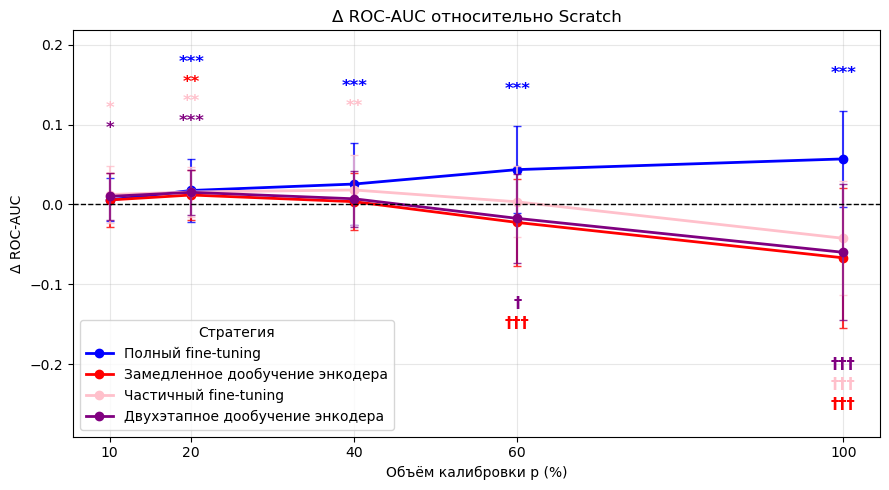

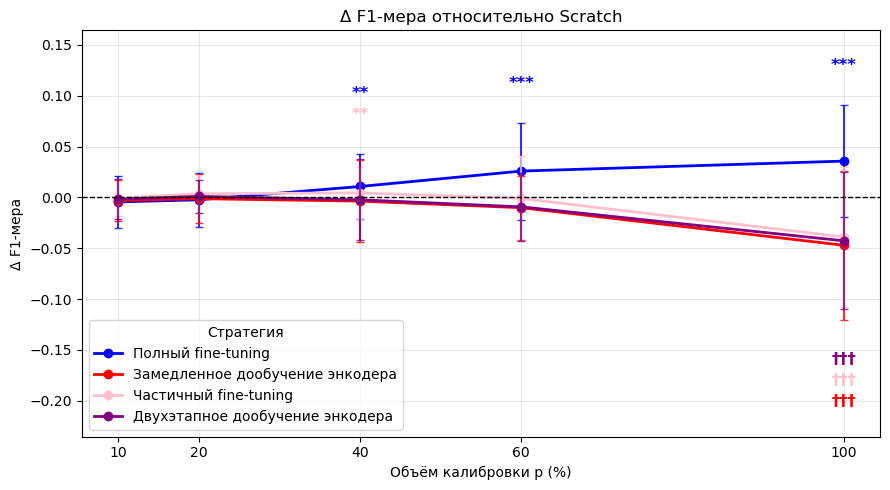

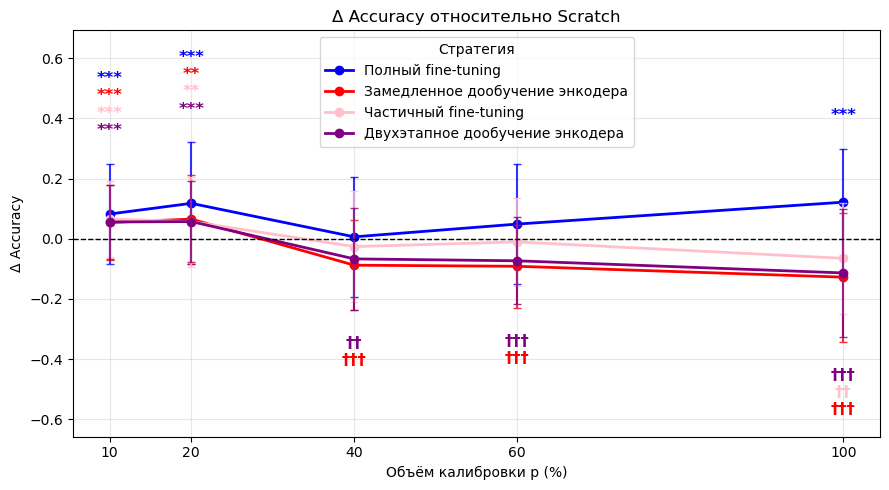

In [13]:
fig = plot_delta_metric("delta_auc", "Δ ROC-AUC", stats_df)
fig = plot_delta_metric("delta_f1", "Δ F1-мера", stats_df)
fig = plot_delta_metric("delta_accuracy", "Δ Accuracy", stats_df)

In [15]:
def save_plot_STAT(plot_func, metric, ylabel, stats_df, filename):
    fig = plot_func(metric, ylabel, stats_df)

    save_path = FIG_DIR / filename
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"Сохранено: {save_path}")

In [16]:
save_plot_STAT(plot_delta_metric, "delta_auc", "Δ ROC-AUC", stats_df, "delta_auc_vs_p_STAT.png")
save_plot_STAT(plot_delta_metric, "delta_f1", "Δ F1-мера", stats_df, "delta_f1_vs_scratch_STAT.png")
save_plot_STAT(plot_delta_metric, "delta_accuracy", "Δ Accuracy", stats_df, "delta_accuracy_vs_scratch_STAT.png")

Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_ch7_15epochs\figures\delta_auc_vs_p_STAT.png
Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_ch7_15epochs\figures\delta_f1_vs_scratch_STAT.png
Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_ch7_15epochs\figures\delta_accuracy_vs_scratch_STAT.png


- для каждого субъекта берём scratch при p=100 как референс;
- сравниваем с этим же субъектом при SSL-стратегии и меньшем p;
- считаем разность:
    - metric_ssl_p - metric_scratch_100
- дальше уже смотрим:
    - среднее / медиану
    - сколько раз разность ≥ 0
    - Wilcoxon (односторонний тест)
    - поправку на множественные сравнения

In [55]:
df_ssl = df_all[df_all["strategy"] != "scratch"].copy()

df_vs_s100 = df_ssl.merge(
    df_scratch_100,
    on="subject_id",
    how="inner"
)

for m in metric_cols:
    df_vs_s100[f"delta_vs_scratch100_{m}"] = df_vs_s100[m] - df_vs_s100[f"{m}_scratch100"]

print("df_vs_s100 shape:", df_vs_s100.shape)
display(df_vs_s100.head())

df_vs_s100 shape: (1220, 16)


,subject_id,p,strategy,auc,f1,accuracy,precision,recall,fdr,group,auc_scratch100,f1_scratch100,accuracy_scratch100,delta_vs_scratch100_auc,delta_vs_scratch100_f1,delta_vs_scratch100_accuracy
0,subj_051,10,full_ft,0.474411,0.210456,0.117603,0.117603,1.000000,0.006504,benchmark,0.791597,0.386343,0.744195,-0.317186,-0.175887,-0.626592
1,subj_051,10,low_lr_encoder,0.561869,0.207612,0.142322,0.116460,0.955414,0.021535,benchmark,0.791597,0.386343,0.744195,-0.229729,-0.178731,-0.601873
2,subj_051,10,partial_ft,0.563124,0.222313,0.284644,0.127451,0.869427,0.020991,benchmark,0.791597,0.386343,0.744195,-0.228473,-0.164031,-0.459551
3,subj_051,10,warmup,0.561710,0.214943,0.201124,0.121515,0.929936,0.020417,benchmark,0.791597,0.386343,0.744195,-0.229887,-0.171400,-0.543071
4,subj_051,20,full_ft,0.494658,0.210456,0.117603,0.117603,1.000000,0.000939,benchmark,0.791597,0.386343,0.744195,-0.296939,-0.175887,-0.626592


##### Быстрая sanity-check проверка

In [56]:
print("Strategies:", sorted(df_vs_s100["strategy"].unique()))
print("p values:", sorted(df_vs_s100["p"].unique()))
print("Subjects:", df_vs_s100["subject_id"].nunique())

Strategies: ['full_ft', 'low_lr_encoder', 'partial_ft', 'warmup']
p values: [np.int64(10), np.int64(20), np.int64(40), np.int64(60), np.int64(100)]
Subjects: 61


#### Wilcoxon для SSL(p) vs scratch(100)

In [59]:
from scipy.stats import wilcoxon

def run_wilcoxon2(values, alternative="two-sided"):
    values = pd.Series(values).dropna()

    if len(values) < 5:
        return np.nan

    try:
        stat, p = wilcoxon(values, alternative=alternative)
        return p
    except Exception:
        return np.nan

## Одна общая таблица для разных объёма калибровки

In [5]:
df_all = pd.read_csv(TAB_DIR / "combined_all_results.csv")

In [17]:
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

def run_wilcoxon2(values, alternative="two-sided"):
    values = pd.Series(values).dropna()

    if len(values) < 5:
        return np.nan

    try:
        stat, p = wilcoxon(values, alternative=alternative)
        return p
    except Exception:
        return np.nan

def build_reference(df_all, p_ref):
    return (
        df_all[
            (df_all["strategy"] == "scratch") &
            (df_all["p"] == p_ref)
        ][["subject_id", "auc", "f1", "accuracy"]]
        .rename(columns={
            "auc": f"auc_scratch{p_ref}",
            "f1": f"f1_scratch{p_ref}",
            "accuracy": f"accuracy_scratch{p_ref}"
        })
        .copy()
    )


def compare_with_reference(df_all, p_ref):
    metric_cols = ["auc", "f1", "accuracy"]

    df_ref = build_reference(df_all, p_ref)
    df_ssl = df_all[df_all["strategy"] != "scratch"].copy()

    df_cmp = df_ssl.merge(df_ref, on="subject_id", how="inner")

    for m in metric_cols:
        df_cmp[f"delta_vs_scratch{p_ref}_{m}"] = (
            df_cmp[m] - df_cmp[f"{m}_scratch{p_ref}"]
        )

    return df_cmp


def build_stats_vs_scratch_refs(df_all, p_refs=[100, 60, 40, 20]):
    metric_cols = ["auc", "f1", "accuracy"]
    all_results = []

    for p_ref in p_refs:
        df_cmp = compare_with_reference(df_all, p_ref=p_ref)

        for (strategy, p), sub in df_cmp.groupby(["strategy", "p"]):
            for m in metric_cols:
                delta_col = f"delta_vs_scratch{p_ref}_{m}"
                vals = sub[delta_col].dropna()

                all_results.append({
                    "strategy": strategy,
                    "p": p,
                    "p_ref": p_ref,
                    "metric": m,
                    "n": len(vals),
                    "mean_diff": vals.mean(),
                    "std_diff": vals.std(),
                    "median_diff": vals.median(),
                    "frac_ge_0": (vals >= 0).mean(),
                    "p_value": run_wilcoxon2(vals),
                })

    stats_all_refs = pd.DataFrame(all_results)

    # Поправка BH отдельно внутри каждой метрики
    # Так аккуратнее, чем смешивать auc/f1/accuracy в одну поправку
    stats_all_refs["p_adj"] = np.nan

    for metric, idx in stats_all_refs.groupby("metric").groups.items():
        pvals = stats_all_refs.loc[idx, "p_value"].values
        stats_all_refs.loc[idx, "p_adj"] = multipletests(
            pvals,
            method="fdr_bh"
        )[1]

    stats_all_refs["significant"] = stats_all_refs["p_adj"] < 0.05

    return stats_all_refs

In [18]:
stats_all_refs = build_stats_vs_scratch_refs(
    df_all,
    p_refs=[100, 60, 40, 20]
)

display(stats_all_refs.head())

,strategy,p,p_ref,metric,n,mean_diff,std_diff,median_diff,frac_ge_0,p_value,p_adj,significant
0,full_ft,10,100,auc,61,-0.142091,0.122528,-0.105921,0.081967,3.986937e-11,5.268640e-10,True
1,full_ft,10,100,f1,61,-0.081143,0.106977,-0.027848,0.163934,1.252905e-09,1.113693e-08,True
2,full_ft,10,100,accuracy,61,-0.210195,0.282113,-0.145833,0.196721,6.987152e-07,2.794861e-06,True
3,full_ft,20,100,auc,61,-0.122821,0.116151,-0.090430,0.098361,1.382486e-10,7.373258e-10,True
4,full_ft,20,100,f1,61,-0.079413,0.100318,-0.028516,0.180328,1.714704e-09,1.247057e-08,True


In [19]:
def make_calibration_matrix(stats_all_refs, metric="auc"):
    strategies = [
        "full_ft",
        "low_lr_encoder",
        "partial_ft",
        "warmup",
    ]

    p_ssl_values = [10, 20, 40, 60]
    p_ref_values = [100, 60, 40, 20]

    df_stat = stats_all_refs[stats_all_refs["metric"] == metric].copy()

    def format_cell(row):
        return (
            f"Δ={row['mean_diff']:.3f}\n"
            f"med = {row['median_diff']:.3f}\n"
            f"p={row['p_adj']:.3g}\n"
            f"({row['frac_ge_0']:.2f})"
        )

    rows = []

    for strategy in strategies:
        for p_ssl in p_ssl_values:
            row_out = {
                "strategy": strategy,
                "p_ssl": f"p={p_ssl}%",
            }

            for p_ref in p_ref_values:
                col_name = f"scratch p={p_ref}%"

                # пустые клетки, где сравнение не имеет смысла
                if p_ssl >= p_ref:
                    row_out[col_name] = ""
                    continue

                sub = df_stat[
                    (df_stat["strategy"] == strategy)
                    & (df_stat["p"] == p_ssl)
                    & (df_stat["p_ref"] == p_ref)
                ]

                if sub.empty:
                    row_out[col_name] = ""
                else:
                    row_out[col_name] = format_cell(sub.iloc[0])

            rows.append(row_out)

    return pd.DataFrame(rows)

In [20]:
table_auc = make_calibration_matrix(stats_all_refs, metric="auc")
table_f1 = make_calibration_matrix(stats_all_refs, metric="f1")
table_acc = make_calibration_matrix(stats_all_refs, metric="accuracy")

display(table_auc)

,strategy,p_ssl,scratch p=100%,scratch p=60%,scratch p=40%,scratch p=20%
0,full_ft,p=10%,Δ=-0.142\nmed = -0.106\np=5.27e-10\n(0.08),Δ=-0.059\nmed = -0.028\np=2.78e-09\n(0.13),Δ=-0.022\nmed = -0.014\np=0.000542\n(0.33),Δ=-0.002\nmed = -0.000\np=0.941\n(0.49)
1,full_ft,p=20%,Δ=-0.123\nmed = -0.090\np=7.37e-10\n(0.10),Δ=-0.039\nmed = -0.019\np=1.28e-05\n(0.25),Δ=-0.003\nmed = -0.002\np=0.725\n(0.49),
2,full_ft,p=40%,Δ=-0.094\nmed = -0.052\np=1.19e-08\n(0.15),Δ=-0.011\nmed = -0.004\np=0.348\n(0.44),,
3,full_ft,p=60%,Δ=-0.040\nmed = -0.026\np=1.93e-05\n(0.25),,,
4,low_lr_encoder,p=10%,Δ=-0.142\nmed = -0.107\np=7.37e-10\n(0.13),Δ=-0.059\nmed = -0.026\np=9.48e-09\n(0.10),Δ=-0.023\nmed = -0.010\np=0.00261\n(0.36),Δ=-0.002\nmed = 0.002\np=0.982\n(0.54)
5,low_lr_encoder,p=20%,Δ=-0.129\nmed = -0.108\np=7.37e-10\n(0.13),Δ=-0.045\nmed = -0.020\np=2.35e-07\n(0.16),Δ=-0.009\nmed = -0.004\np=0.538\n(0.44),
6,low_lr_encoder,p=40%,Δ=-0.116\nmed = -0.081\np=5.27e-10\n(0.07),Δ=-0.033\nmed = -0.013\np=2.46e-05\n(0.23),,
7,low_lr_encoder,p=60%,Δ=-0.106\nmed = -0.081\np=1.48e-09\n(0.15),,,
8,partial_ft,p=10%,Δ=-0.135\nmed = -0.106\np=1.11e-09\n(0.11),Δ=-0.052\nmed = -0.024\np=1.07e-07\n(0.18),Δ=-0.016\nmed = -0.007\np=0.0188\n(0.36),Δ=0.005\nmed = 0.004\np=0.133\n(0.59)
9,partial_ft,p=20%,Δ=-0.125\nmed = -0.094\np=6.95e-10\n(0.08),Δ=-0.041\nmed = -0.015\np=3.96e-07\n(0.20),Δ=-0.005\nmed = 0.003\np=0.935\n(0.54),


In [35]:
out_path = TAB_DIR / "calibration_reduction_tables.xlsx"

with pd.ExcelWriter(out_path) as writer:
    table_auc.to_excel(writer, sheet_name="ROC-AUC", index=False)
    table_f1.to_excel(writer, sheet_name="F1", index=False)
    table_acc.to_excel(writer, sheet_name="Accuracy", index=False)

out_path

WindowsPath('c:/Users/Таисия/Desktop/МФТИ/Диплом_BCI/diploma-bciP300-ssl/outputs/downstream/test_ch7_15epochs/tables/calibration_reduction_tables.xlsx')

In [35]:
metric = "auc"  # 'auc' или "f1", "accuracy"

important_cells = stats_all_refs[
    (stats_all_refs["metric"] == metric) &
    ((stats_all_refs["mean_diff"] >= 0) |
    (stats_all_refs["median_diff"] >= 0))
].copy()

important_cells = important_cells[
    important_cells["p"] < important_cells["p_ref"]
]

important_cells = important_cells[
    ["strategy", "p", "p_ref", "mean_diff", "median_diff", "p_adj", "frac_ge_0"]
].sort_values(["strategy", "p", "p_ref"])

for _, row in important_cells.iterrows():
    print(
        f"{row['strategy']} | p={row['p']} vs scratch p={row['p_ref']} → "
        f"Δ={row['mean_diff']:.3f}, med={row['median_diff']:.3f}, "
        f"p={row['p_adj']:.3g}, ({row['frac_ge_0']:.2f})"
    )

low_lr_encoder | p=10 vs scratch p=20 → Δ=-0.002, med=0.002, p=0.982, (0.54)
partial_ft | p=10 vs scratch p=20 → Δ=0.005, med=0.004, p=0.133, (0.59)
partial_ft | p=20 vs scratch p=40 → Δ=-0.005, med=0.003, p=0.935, (0.54)
warmup | p=10 vs scratch p=20 → Δ=0.003, med=0.002, p=0.986, (0.54)
warmup | p=20 vs scratch p=40 → Δ=-0.006, med=0.000, p=0.986, (0.51)


### Графики

In [28]:
def plot_delta_vs_scratch_ref(
    stats_all_refs,
    strategy,
    p_ref,
    metric="auc",
    p_values=(10, 20, 40, 60, 100),
    highlight_p=None,
    equal_band=0.01,
    save=False,
):
    fig, ax = plt.subplots(figsize=(8, 5))

    sub = stats_all_refs[
        (stats_all_refs["strategy"] == strategy)
        & (stats_all_refs["p_ref"] == p_ref)
        & (stats_all_refs["metric"] == metric)
        & (stats_all_refs["p"].isin(p_values))
    ].copy()

    sub = (
        sub
        .set_index("p")
        .reindex(p_values)
        .reset_index()
    )

    x = sub["p"]
    y = sub["mean_diff"]

    label = (
        f"'{STRATEGY_RU.get(strategy, strategy)}' "
        f"vs 'Обучение с нуля' (p={p_ref})"
    )

    ax.plot(
        x, y,
        marker="o",
        linewidth=2,
        color=COLORS[strategy],
        label=label,
    )

    # error bars если есть std
    if "std_diff" in sub.columns:
        yerr = sub["std_diff"]

        ax.errorbar(
            x, y,
            yerr=yerr,
            fmt="none",
            ecolor=COLORS[strategy],
            capsize=3,
            alpha=0.8,
        )

    ax.axhline(0, linestyle="--", linewidth=1, color="black")

    # зона равенства
    ax.axhspan(
        -equal_band,
        equal_band,
        color="gray",
        alpha=0.15,
        label=f"≈ одинаковое качество (±{equal_band})",
    )

    # выделение точки
    if highlight_p is not None and highlight_p in sub["p"].values:
        row_h = sub[sub["p"] == highlight_p].iloc[0]

        ax.scatter(
            highlight_p,
            row_h["mean_diff"],
            color="red",
            s=80,
            zorder=5,
            label=f"p={highlight_p}: без потери качества",
        )

    metric_ru = {
        "auc": "ROC-AUC",
        "f1": "F1-мера",
        "accuracy": "Accuracy",
    }.get(metric, metric)

    ax.set_xticks(list(p_values))
    ax.set_xlabel("Объём калибровки p (%)")
    ax.set_ylabel(f"Δ {metric_ru} относительно обучения с нуля (p={p_ref})")
    ax.set_title(
        f"{metric_ru}: {STRATEGY_RU.get(strategy, strategy)} vs Scratch (p={p_ref})"
    )

    ax.legend(title="Сравнение")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()

    # --- автосохранение ---
    if save:
        metric_name = metric.lower()
        strategy_name = strategy.lower()
        filename = f"{metric_name}_{strategy_name}_vs_scratch{p_ref}.png"

        save_path = FIG_DIR / filename

        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)

        print(f"Сохранено: {save_path}")
    else:
        plt.show()

    return fig

#### Рисуем

STRATEGY_RU = {
    "scratch": "Обучение с нуля",
    "full_ft": "Полный fine-tuning",
    "low_lr_encoder": "Замедленное дообучение энкодера",
    "partial_ft": "Частичный fine-tuning",
    "warmup": "Двухэтапное дообучение энкодера",
}

Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test_ch7_15epochs\figures\auc_warmup_vs_scratch40.png


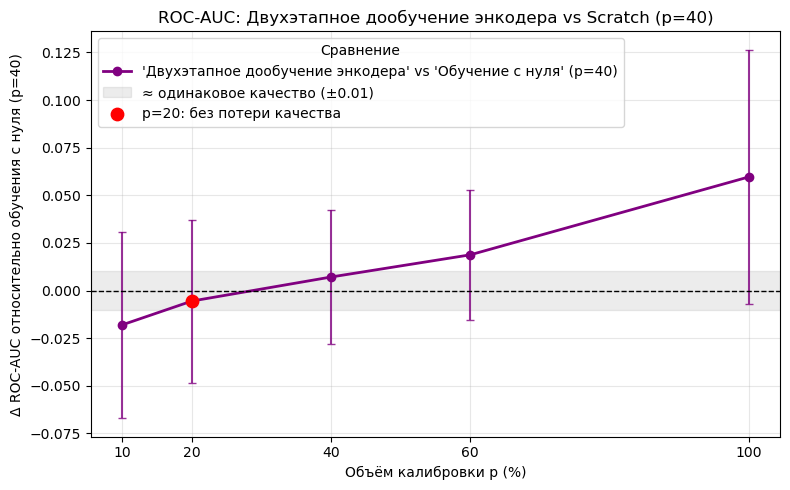

In [34]:
plot_delta_vs_scratch_ref(
    stats_all_refs,
    strategy="warmup",
    p_ref=40,
    metric="auc",
    highlight_p=20,
    save=True
)